#### 1. Extração da base de dados

In [25]:
import kagglehub 
from pathlib import Path
import shutil
import sys
from src.config import RAW_DATA_PATH

# Configura caminho para pasta raiz tech_challenge_5/
PROJECT_ROOT = Path.cwd().parent

# Adiciona a raiz do projeto ao caminho de busca do Python,
# permitindo importar módulos da pasta src (ex: src.config) nos notebooks.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Download latest version
download_path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
print("Path to dataset files:", download_path)

# Copia dados para data/raw
download_path = Path(download_path)
destino = RAW_DATA_PATH
destino.mkdir(parents=True, exist_ok=True)

for arquivo in download_path.iterdir():
    if arquivo.is_file():
        shutil.copy2(arquivo, destino / arquivo.name)

print("Arquivos copiados com sucesso!")

c:\Users\alice\OneDrive\Área de Trabalho\tech_challenge_5
Path to dataset files: C:\Users\alice\.cache\kagglehub\datasets\henriqueyamahata\bank-marketing\versions\1
Arquivos copiados com sucesso!


#### 2. Leitura dos dados

In [40]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    RAW_DATA_PATH / "bank-additional-full.csv",
    sep=";"
)

# Visualiza amostra de dados
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [48]:
print(f"O dataset possui {np.shape(df)[0]} linhas e {np.shape(df)[1]} colunas.")
print(f"As colunas disponíveis são: {df.columns.tolist()}")
print("ATENÇÃO: Existem dados desde Maio/2008 até Novembro/2010, mas a base não possui dados sobre o ano.")

O dataset possui 41188 linhas e 20 colunas.
As colunas disponíveis são: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
ATENÇÃO: Existem dados desde Maio/2008 até Novembro/2010, mas a base não possui dados sobre o ano.


#### 3. Exploração de dados

O dicionário dos dados está detalhado em: *...\data\data_dictionary.md*

**Dicionário das Variáveis**

| Variável | Tipo | Descrição |
|---|---|---|
| age | Numérica | Idade do cliente em anos. |
| job | Categórica | Tipo de ocupação/profissão do cliente. Exemplos: admin, technician, entrepreneur, student. |
| marital | Categórica | Estado civil do cliente. Valores possíveis: married, single, divorced. |
| education | Categórica | Nível de escolaridade do cliente. |
| default | Categórica | Indica se o cliente possui histórico de inadimplência/crédito em atraso. |
| housing | Categórica | Indica se o cliente possui financiamento imobiliário. |
| loan | Categórica | Indica se o cliente possui empréstimo pessoal. |
| contact | Categórica | Tipo de canal utilizado para contato com o cliente. |
| month | Categórica | Mês em que ocorreu o último contato da campanha. |
| day_of_week | Categórica | Dia da semana do último contato. |
| duration | Numérica | Duração do último contato em segundos. Deve ser removida da modelagem por representar informação posterior ao início da interação. |
| campaign | Numérica | Quantidade de contatos realizados durante a campanha atual para esse cliente. |
| pdays | Numérica | Número de dias desde o último contato de uma campanha anterior. |
| previous | Numérica | Quantidade de contatos realizados antes da campanha atual. |
| poutcome | Categórica | Resultado da campanha anterior. |
| emp.var.rate | Numérica | Taxa de variação do emprego (indicador econômico). Note que o valor pode ser negativo, que significaria uma redução na taxa de emprego (um cenário econômico menos favorável).|
| cons.price.idx | Numérica | Índice de preços ao consumidor. Mede como os preços dos produtos e serviços estão variando ao longo do tempo em uma economia. |
| cons.conf.idx | Numérica | Índice de confiança do consumidor. Mede o nível de otimismo ou pessimismo das pessoas em relação à economia. Se as pessoas estão mais otimistas = maior propensão a consumir/investir |
| euribor3m | Numérica | Taxa Euribor de 3 meses, indicador econômico europeu. Ela é uma taxa de juros de referência do mercado europeu, que indica o custo médio pelo qual bancos europeus emprestam dinheiro entre si por um período de três meses |
| nr.employed | Numérica | Número de empregados no setor econômico no período da campanha. |
| y | Binária (target) | Resultado da campanha: cliente aceitou (`yes`) ou recusou (`no`) a oferta. |

In [44]:
''' 
Remove colunas data leakage (vazamento de dados)

duration: indica quanto tempo o contato durou depois que ele 
    já aconteceu. No histórico, maior tempo tendeu a converter 
    mais. No momento da inferência esses dados não estariam 
    disponíveis.

'''
columns_drop = [
        'duration',
        ]

df = df.drop(columns_drop, axis=1)

In [45]:
df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**Considerações:**
* Média de idade é de 40 anos, e varia de 17 a 98 anos
* Os clientes tiveram em média 2.5 contatos e existem clientes que tiveram 56 contatos (verificar outlier)
* Os clientes tem um espaço médio de 962 dias (2.6 anos) entre um contato e outro, mas tiveram clientes com diferença de 0 dias
* A média de contato é menor que 1 (0.17), mas o máximo é 7 

Distribuição do target

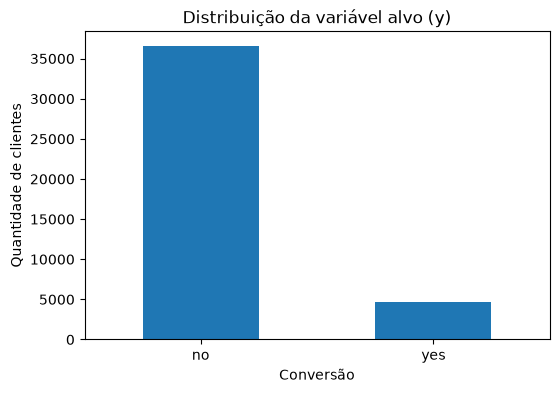

In [62]:
# Criar versão numérica do target
df_corr = df.copy()

df_corr["y_num"] = df_corr["y"].map({
    "no": 0,
    "yes": 1
})

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["y"].value_counts().plot(
    kind="bar"
)

plt.title("Distribuição da variável alvo (y)")
plt.xlabel("Conversão")
plt.ylabel("Quantidade de clientes")

plt.xticks(rotation=0)

plt.show()

Visualizar indicadores de mercado na época (Maio/2008 até Novembro/2010)

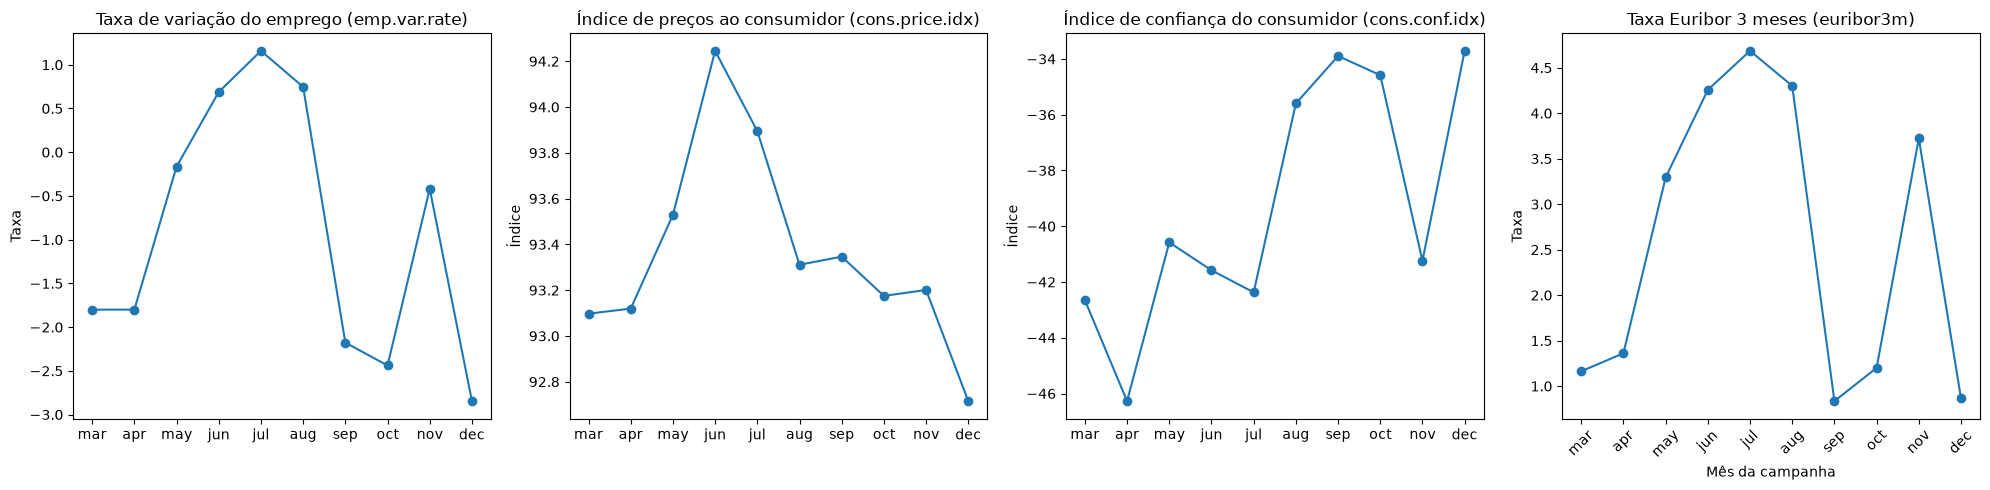

In [59]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1, 
    4, 
    figsize=(20, 5),
    sharex=True
)

# emp.var.rate
axes[0].plot(
    df_market.index,
    df_market["emp.var.rate"],
    marker="o"
)
axes[0].set_title("Taxa de variação do emprego (emp.var.rate)")
axes[0].set_ylabel("Taxa")

# cons.price.idx
axes[1].plot(
    df_market.index,
    df_market["cons.price.idx"],
    marker="o"
)
axes[1].set_title("Índice de preços ao consumidor (cons.price.idx)")
axes[1].set_ylabel("Índice")

# cons.conf.idx
axes[2].plot(
    df_market.index,
    df_market["cons.conf.idx"],
    marker="o"
)
axes[2].set_title("Índice de confiança do consumidor (cons.conf.idx)")
axes[2].set_ylabel("Índice")

# euribor3m
axes[3].plot(
    df_market.index,
    df_market["euribor3m"],
    marker="o"
)
axes[3].set_title("Taxa Euribor 3 meses (euribor3m)")
axes[3].set_ylabel("Taxa")

plt.xlabel("Mês da campanha")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [63]:
import seaborn as sns

numeric_cols = df_corr.select_dtypes(
    include="number"
).columns

corr = (
    df_corr[numeric_cols]
    .corr()
)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr[["y_num"]]
    .sort_values(
        by="y_num",
        ascending=False
    ),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação das variáveis numéricas com conversão (y)")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

* A base possui muitos valores ausentes?
* Há risco de vazamento temporal?
* Distribuição do target
* Conversão por profissão
* Conversão por escolaridade
* Conversão por histórico de campanha
* Conversão por canal
* Matriz ou tabela de valores ausentes